# Multi-Source News Sentiment Analysis Pipeline

**Data Sources:**
- [NDTV](https://www.ndtv.com) — via RSS feed
- [Times of India](https://timesofindia.indiatimes.com) — via RSS feed
- [NewsLive TV](https://newslivetv.com) — via HTML scrape (BeautifulSoup)

**Goal:** Scrape live headlines from three Indian news sources, run TextBlob NLP sentiment analysis on each headline, persist structured results in SQLite, and visualize sentiment patterns across sources.

**Pipeline:**
1. Data Collection — RSS + HTML scraping
2. Sentiment Analysis — TextBlob polarity scoring
3. SQLite Storage — persist records with timestamps
4. Visualizations — sentiment by source, polarity distribution, word cloud

In [1]:
# Install required packages (run once)
!pip install -q feedparser textblob wordcloud
!python -m textblob.download_corpora lite

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 1.6 MB/s eta 0:00:00
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
Finished.


In [2]:
import sqlite3
import requests
import feedparser
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from bs4 import BeautifulSoup
from textblob import TextBlob
from wordcloud import WordCloud
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 1. Data Collection

Three scrapers run independently and are combined into a single DataFrame.

| Source | Method | URL |
|---|---|---|
| NDTV | RSS (feedparser) | feeds.feedburner.com/ndtvnews-top-stories |
| Times of India | RSS (feedparser) | timesofindia.indiatimes.com/rssfeedstopstories.cms |
| NewsLive TV | HTML scrape (BeautifulSoup) | newslivetv.com |

In [3]:
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (compatible; NewsSentimentBot/1.0)'
}

def scrape_rss(feed_url: str, source_name: str, limit: int = 20) -> list[dict]:
    """Parse an RSS feed and return a list of headline dicts."""
    feed = feedparser.parse(feed_url)
    records = []
    for entry in feed.entries[:limit]:
        title = entry.get('title', '').strip()
        if title:
            records.append({'headline': title, 'source': source_name})
    print(f'  {source_name}: {len(records)} headlines fetched')
    return records


def scrape_newslive(limit: int = 20) -> list[dict]:
    """Scrape news excerpts from newslivetv.com using BeautifulSoup."""
    try:
        resp = requests.get('https://newslivetv.com', headers=HEADERS, timeout=15)
        soup = BeautifulSoup(resp.text, 'html.parser')
        excerpts = soup.find_all('div', class_='td-excerpt')
        records = []
        for tag in excerpts[:limit]:
            text = tag.get_text(strip=True)
            if text:
                records.append({'headline': text, 'source': 'NewsLive'})
        print(f'  NewsLive: {len(records)} headlines fetched')
        return records
    except Exception as e:
        print(f'  NewsLive scrape failed: {e}')
        return []


print('Collecting headlines...')
all_records = []
all_records += scrape_rss(
    'https://feeds.feedburner.com/ndtvnews-top-stories', 'NDTV'
)
all_records += scrape_rss(
    'https://timesofindia.indiatimes.com/rssfeedstopstories.cms', 'Times of India'
)
all_records += scrape_newslive()

print(f'\nTotal headlines collected: {len(all_records)}')

  NDTV: 20 headlines fetched
  Times of India: 20 headlines fetched
  NewsLive: 18 headlines fetched

Total headlines collected: 58


In [4]:
# Build raw DataFrame
df = pd.DataFrame(all_records)
df = df.drop_duplicates(subset='headline').reset_index(drop=True)
print(f'After deduplication: {len(df)} headlines')
print('\nSample headlines per source:')
df.groupby('source').head(2)[['source', 'headline']]

After deduplication: 57 headlines

Sample headlines per source:


,source,headline
0,NDTV,"""Military Dictatorship, Clerical Facade"": Fare..."
1,NDTV,Man Jumps From 23rd Floor With 2-Year-Old Daug...
20,Times of India,'Distorted picture of India': MEA slams US rep...
21,Times of India,The invisible arc of power: How ballistic miss...
40,NewsLive,"As the Middle East War entered its third week,..."
41,NewsLive,The upcoming Assembly elections in Assam will ...


## 2. Sentiment Analysis

TextBlob computes a **polarity score** in the range `[-1.0, +1.0]`:

| Range | Label |
|---|---|
| polarity > 0.05 | Positive |
| polarity < -0.05 | Negative |
| -0.05 ≤ polarity ≤ 0.05 | Neutral |

Thresholds are intentionally tight (±0.05) because news headlines are factual and lean neutral by nature.

In [7]:
def classify_sentiment(polarity: float) -> str:
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    return 'Neutral'


df['polarity']  = df['headline'].apply(lambda h: TextBlob(h).sentiment.polarity)
df['subjectivity'] = df['headline'].apply(lambda h: TextBlob(h).sentiment.subjectivity)
df['sentiment'] = df['polarity'].apply(classify_sentiment)
df['scraped_at'] = datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')

print('Sentiment distribution (all sources):')
print(df['sentiment'].value_counts().to_string())
print(f'\nMean polarity: {df["polarity"].mean():.4f}')
df[['headline', 'source', 'polarity', 'sentiment']].head(10)

Sentiment distribution (all sources):
sentiment
Neutral     36
Positive    14
Negative     7

Mean polarity: 0.0483


,headline,source,polarity,sentiment
0,"""Military Dictatorship, Clerical Facade"": Fare...",NDTV,-0.100000,Negative
1,Man Jumps From 23rd Floor With 2-Year-Old Daug...,NDTV,0.000000,Neutral
2,Poll Body Appoints Ex-Bureaucrat Manjeet Singh...,NDTV,0.357143,Positive
3,Court Sends 2 Accused To 15-Day Judicial Custo...,NDTV,0.000000,Neutral
4,Netanyahu Posts New Video After Grok Flags His...,NDTV,0.136364,Positive
5,Opinion: Opinion | The Story Of Bengal's 'Real...,NDTV,0.200000,Positive
6,"Not Just Bengal, Election Commission Transferr...",NDTV,0.000000,Neutral
7,"""Anti-Women, Anti-Bengali"": Mamata Banerjee Sl...",NDTV,0.000000,Neutral
8,Need To Get Out Of Mindset That Only Delhi Req...,NDTV,-0.100000,Negative
9,"NDTV Exclusive: Rifle, Tactical Gear And A Lon...",NDTV,-0.050000,Neutral


## 3. SQLite Storage

Results are persisted to `news_sentiment.db` — a local SQLite database.  
Each run appends new records (the table is `CREATE IF NOT EXISTS`).  
This makes the tool re-runnable: you can track sentiment trends across multiple scraping sessions.

In [8]:
DB_PATH = 'news_sentiment.db'

conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

cur.execute('''
    CREATE TABLE IF NOT EXISTS articles (
        id              INTEGER PRIMARY KEY AUTOINCREMENT,
        headline        TEXT NOT NULL,
        source          TEXT NOT NULL,
        polarity        REAL,
        subjectivity    REAL,
        sentiment_label TEXT,
        scraped_at      TEXT
    )
''')
conn.commit()

rows = [
    (row['headline'], row['source'], row['polarity'],
     row['subjectivity'], row['sentiment'], row['scraped_at'])
    for _, row in df.iterrows()
]
cur.executemany(
    'INSERT INTO articles (headline, source, polarity, subjectivity, sentiment_label, scraped_at) '
    'VALUES (?, ?, ?, ?, ?, ?)',
    rows
)
conn.commit()
print(f'Inserted {len(rows)} records into {DB_PATH}')

# Verify with a query
total = cur.execute('SELECT COUNT(*) FROM articles').fetchone()[0]
print(f'Total records in DB (all runs): {total}')

Inserted 57 records into news_sentiment.db
Total records in DB (all runs): 114


In [9]:
# Query: sentiment breakdown per source from DB
query = '''
    SELECT source, sentiment_label, COUNT(*) as count
    FROM articles
    WHERE scraped_at = (
        SELECT MAX(scraped_at) FROM articles
    )
    GROUP BY source, sentiment_label
    ORDER BY source, sentiment_label
'''
db_df = pd.read_sql_query(query, conn)
conn.close()
print('Latest run — sentiment by source (from DB):')
db_df

Latest run — sentiment by source (from DB):


,source,sentiment_label,count
0,NDTV,Negative,3
1,NDTV,Neutral,12
2,NDTV,Positive,5
3,NewsLive,Negative,2
4,NewsLive,Neutral,11
5,NewsLive,Positive,4
6,Times of India,Negative,2
7,Times of India,Neutral,13
8,Times of India,Positive,5


## 4. Visualizations

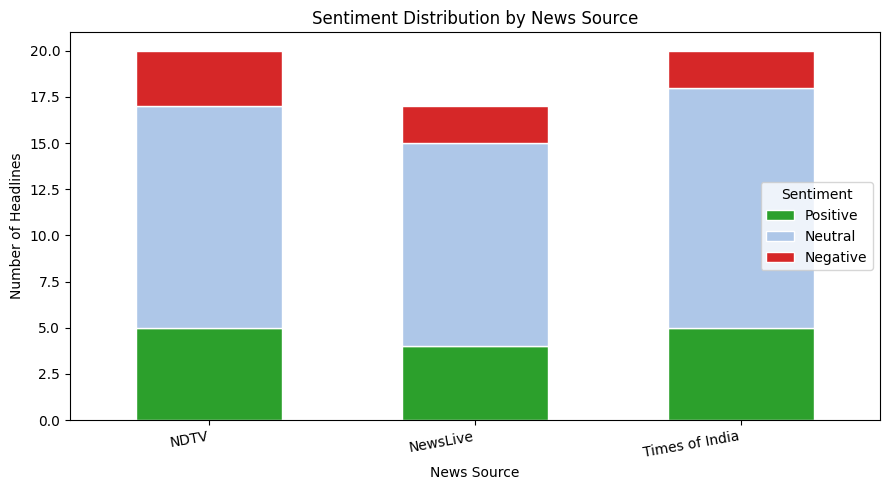

In [10]:
# Plot 1 — Stacked bar: sentiment distribution per source
pivot = df.groupby(['source', 'sentiment']).size().unstack(fill_value=0)
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['Positive', 'Neutral', 'Negative']]

colors = {'Positive': '#2ca02c', 'Neutral': '#aec7e8', 'Negative': '#d62728'}
ax = pivot.plot(
    kind='bar', stacked=True, figsize=(9, 5),
    color=[colors[c] for c in pivot.columns],
    edgecolor='white', width=0.55
)
ax.set_xlabel('News Source')
ax.set_ylabel('Number of Headlines')
ax.set_title('Sentiment Distribution by News Source')
ax.legend(title='Sentiment')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.savefig('sentiment_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

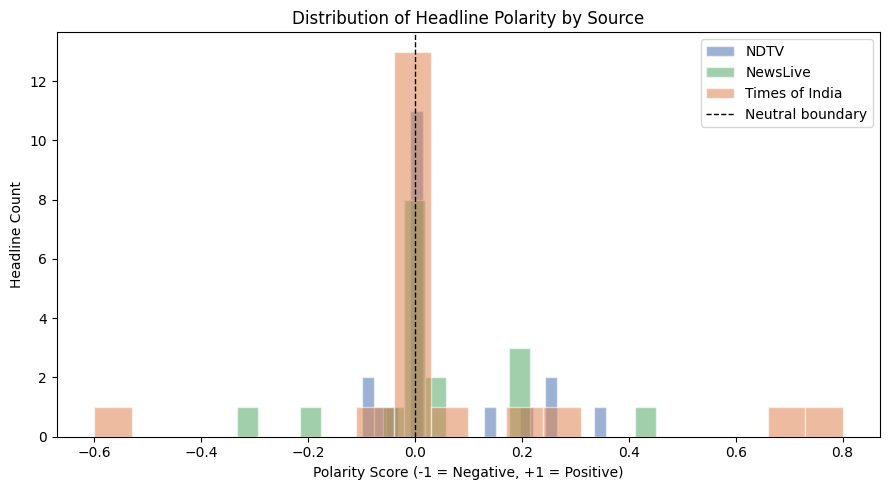

In [11]:
# Plot 2 — Polarity score distribution (histogram + KDE)
fig, ax = plt.subplots(figsize=(9, 5))

source_colors = {'NDTV': '#4C72B0', 'Times of India': '#DD8452', 'NewsLive': '#55A868'}
for source, grp in df.groupby('source'):
    color = source_colors.get(source, '#888888')
    ax.hist(grp['polarity'], bins=20, alpha=0.55,
            label=source, color=color, edgecolor='white')

ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Neutral boundary')
ax.set_xlabel('Polarity Score (-1 = Negative, +1 = Positive)')
ax.set_ylabel('Headline Count')
ax.set_title('Distribution of Headline Polarity by Source')
ax.legend()
plt.tight_layout()
plt.savefig('polarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

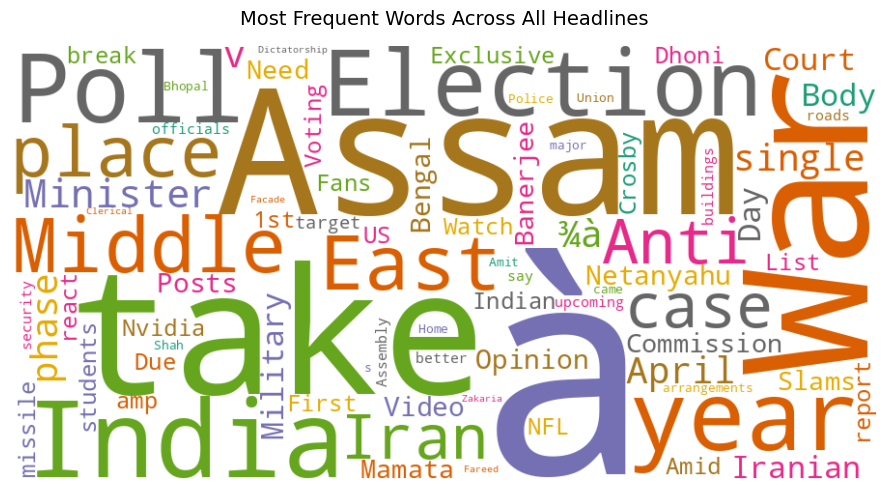

In [12]:
# Plot 3 — Word Cloud of most frequent headline words
from wordcloud import STOPWORDS

all_text = ' '.join(df['headline'].tolist())
stopwords = set(STOPWORDS) | {
    'says', 'said', 'new', 'one', 'two', 'will', 'also', 'after'
}

wc = WordCloud(
    width=900, height=450,
    background_color='white',
    stopwords=stopwords,
    colormap='Dark2',
    max_words=80,
    collocations=False
).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words Across All Headlines', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('headline_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Summary stats table
summary = df.groupby('source').agg(
    Total_Headlines=('headline', 'count'),
    Avg_Polarity=('polarity', lambda x: round(x.mean(), 4)),
    Avg_Subjectivity=('subjectivity', lambda x: round(x.mean(), 4)),
    Positive=('sentiment', lambda x: (x == 'Positive').sum()),
    Neutral=('sentiment', lambda x: (x == 'Neutral').sum()),
    Negative=('sentiment', lambda x: (x == 'Negative').sum()),
).reset_index()
print('Final Summary:')
summary

Final Summary:


,source,Total_Headlines,Avg_Polarity,Avg_Subjectivity,Positive,Neutral,Negative
0,NDTV,20,0.0436,0.2253,5,12,3
1,NewsLive,17,0.0329,0.2731,4,11,2
2,Times of India,20,0.0660,0.2445,5,13,2
